In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def load_img():
    blank_img =np.zeros((600,600))
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(blank_img,text='ABCDE',org=(50,300), fontFace=font,fontScale= 5,color=(255,255,255),thickness=25,lineType=cv2.LINE_AA)
    return blank_img

In [3]:
def display_img(img):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap='gray')

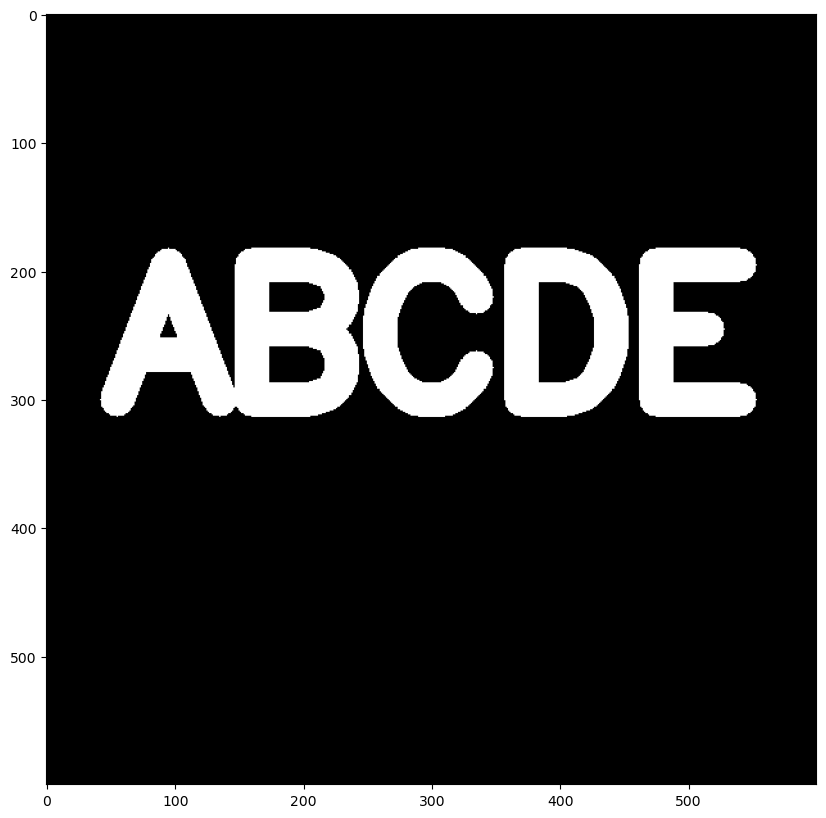

In [9]:
img = load_img()
display_img(img)

In [6]:
# Erosion
kernel = np.ones((5, 5), dtype = np.uint8)
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

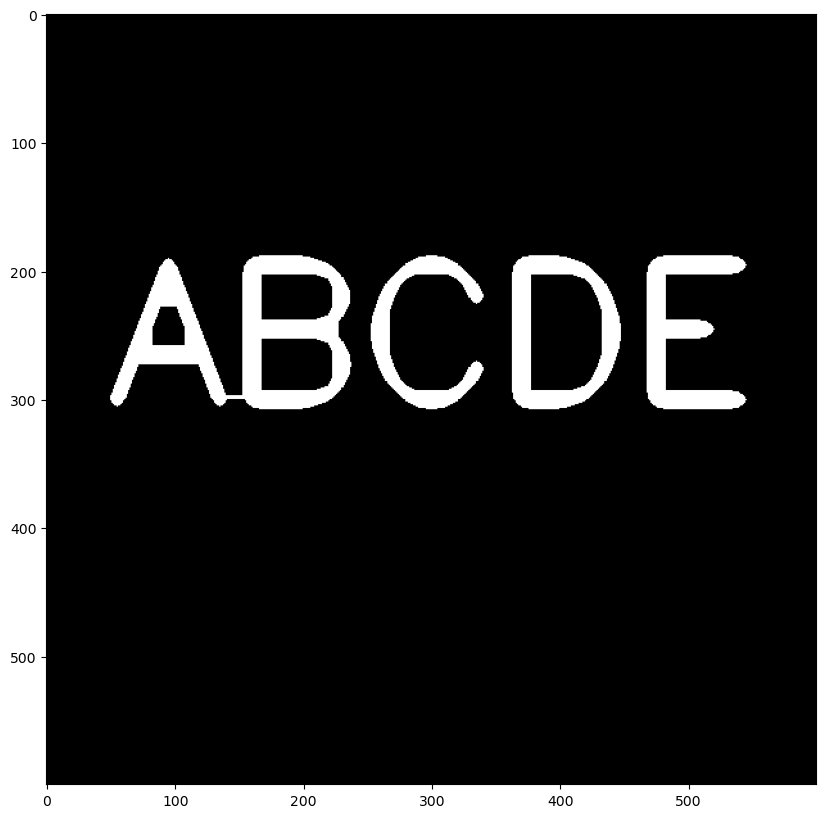

In [10]:
result = cv2.erode(img, kernel, iterations = 3)
display_img(result)
# The foreground text in white gets eroded away.

[[0 1 0 ... 0 1 0]
 [0 0 1 ... 0 1 0]
 [1 0 1 ... 1 1 1]
 ...
 [0 0 0 ... 0 1 1]
 [1 0 0 ... 0 0 1]
 [1 0 1 ... 0 1 1]]


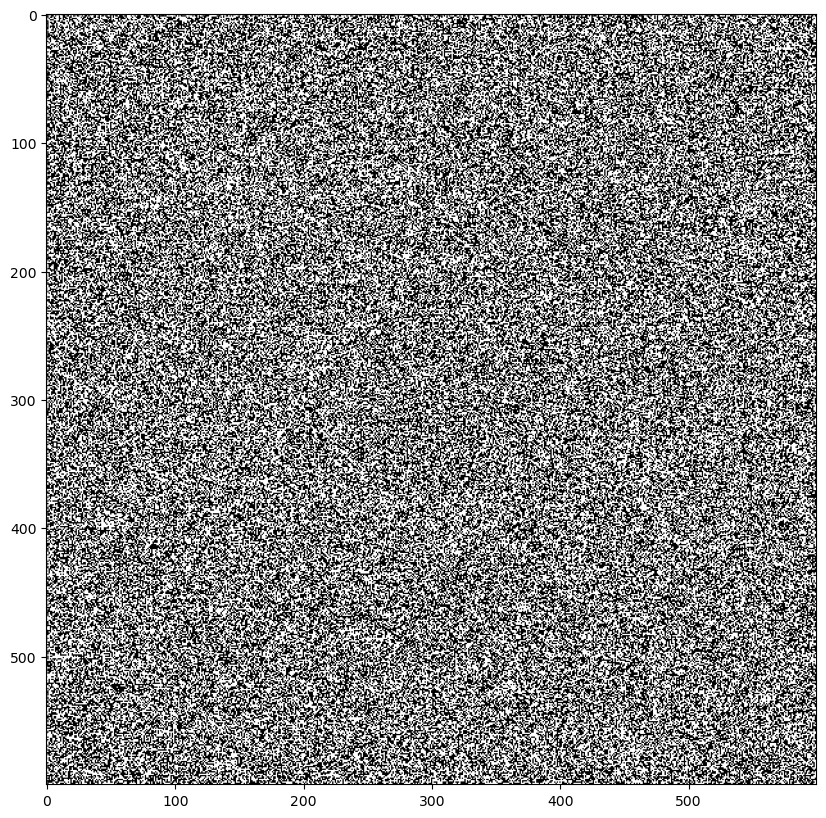

In [28]:
# Opening - Technique to remove noise
img = load_img()
white_noise = np.random.randint(low = 0, high = 2, size = (600, 600))
print(white_noise)
display_img(white_noise)

In [29]:
print(img.max())
# Max value is 255

# Convert white_noise to 0s and 255s
white_noise = white_noise * 255
#display_img(white_noise)
white_noise

255.0


array([[  0, 255,   0, ...,   0, 255,   0],
       [  0,   0, 255, ...,   0, 255,   0],
       [255,   0, 255, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ...,   0, 255, 255],
       [255,   0,   0, ...,   0,   0, 255],
       [255,   0, 255, ...,   0, 255, 255]])

In [30]:
noise_img = white_noise + img

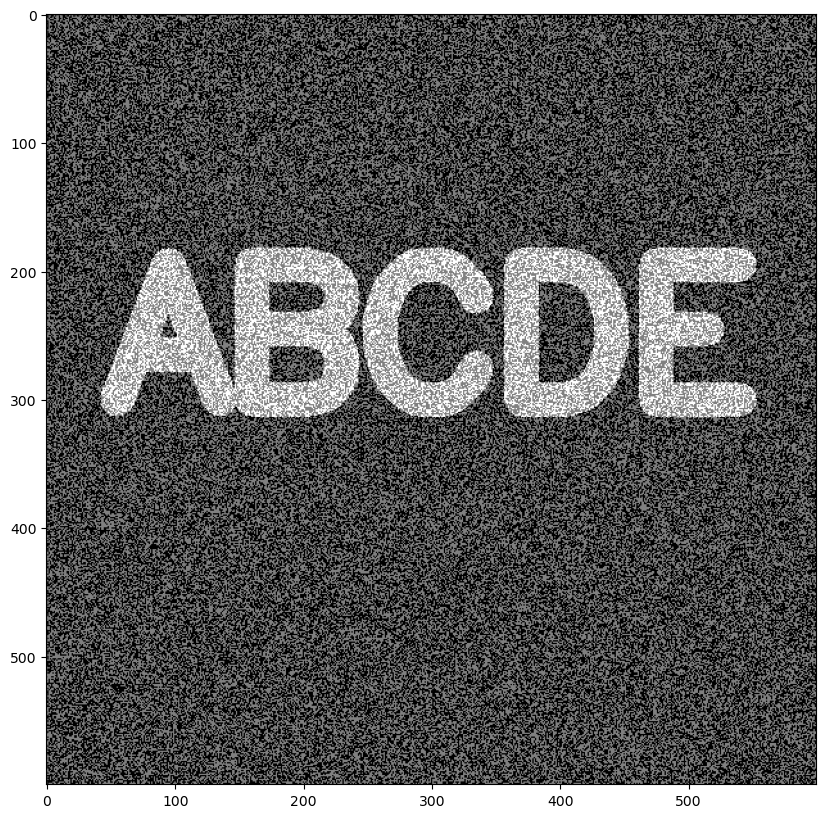

In [31]:
display_img(noise_img)

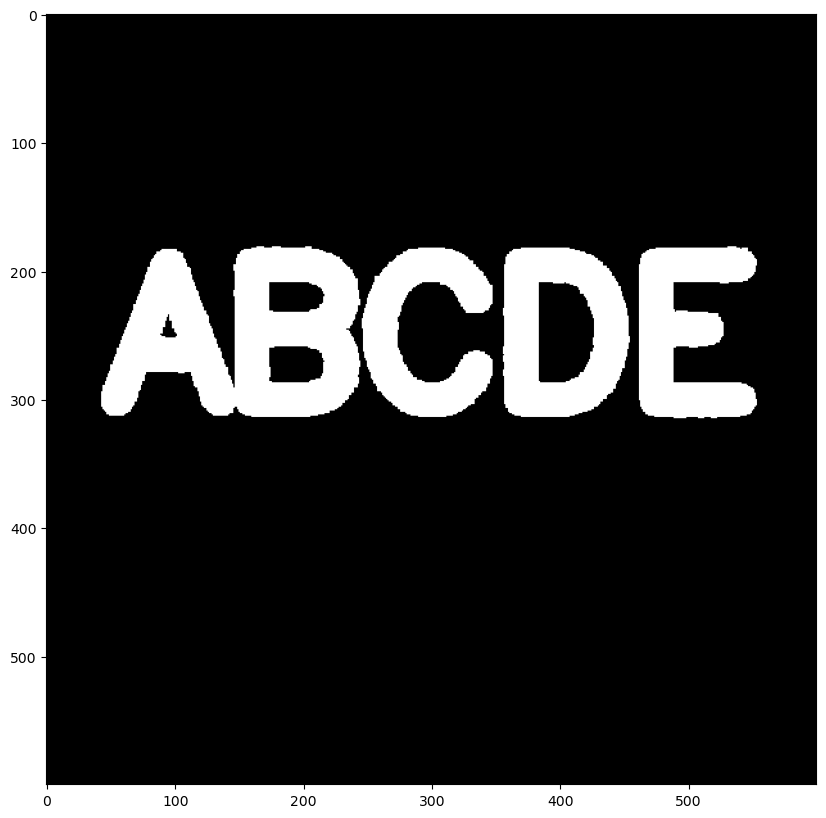

In [32]:
# Now to remove the noise
opening = cv2.morphologyEx(noise_img, cv2.MORPH_OPEN, kernel)
display_img(opening)

[[   0    0 -255 ...    0 -255    0]
 [-255    0 -255 ...    0 -255 -255]
 [-255 -255    0 ...    0 -255 -255]
 ...
 [-255    0    0 ...    0 -255 -255]
 [   0 -255    0 ...    0    0    0]
 [-255    0    0 ... -255 -255 -255]]


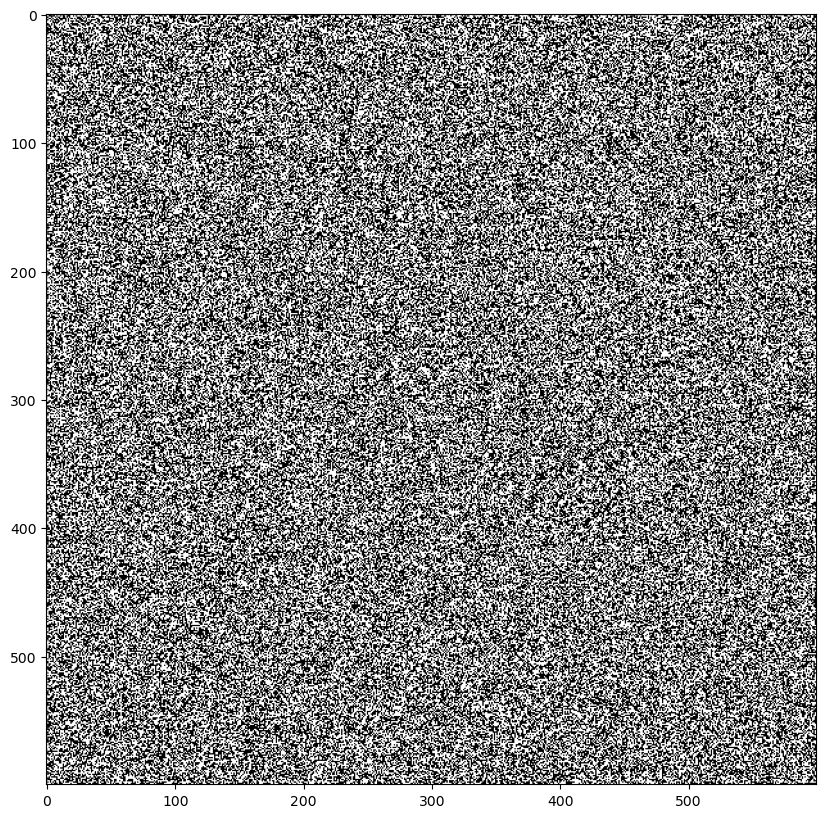

In [33]:
# To remove foreground noise
img = load_img()
black_noise = np.random.randint(low = 0, high = 2, size = (600, 600))

black_noise = black_noise * -255
print(black_noise)
display_img(black_noise)

[[   0.    0. -255. ...    0. -255.    0.]
 [-255.    0. -255. ...    0. -255. -255.]
 [-255. -255.    0. ...    0. -255. -255.]
 ...
 [-255.    0.    0. ...    0. -255. -255.]
 [   0. -255.    0. ...    0.    0.    0.]
 [-255.    0.    0. ... -255. -255. -255.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


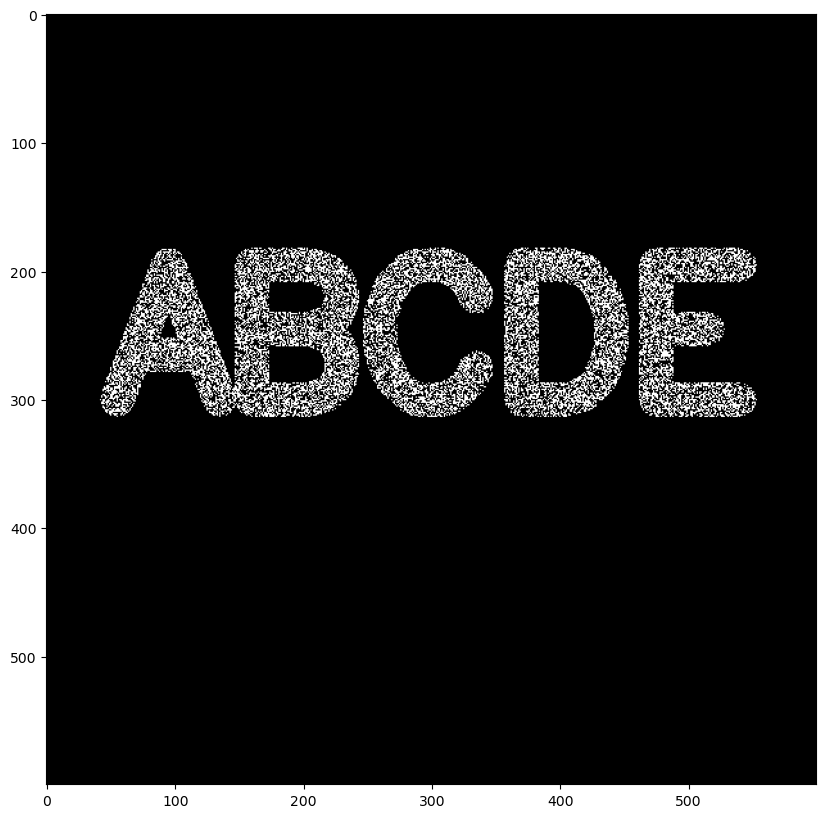

In [36]:
black_noise_img = img + black_noise
print(black_noise_img)
# Set all -255 back to 0
black_noise_img[black_noise_img == -255] = 0
print(black_noise_img)
display_img(black_noise_img)

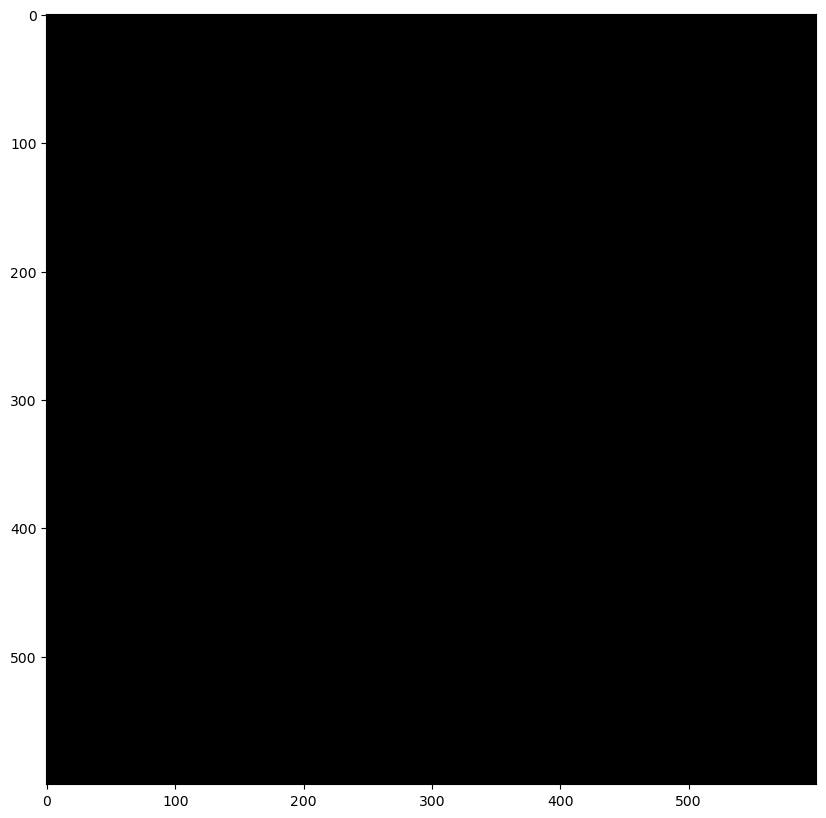

In [37]:
# Try opening on the same
opening2 = cv2.morphologyEx(black_noise_img, cv2.MORPH_OPEN, kernel)
display_img(opening2)

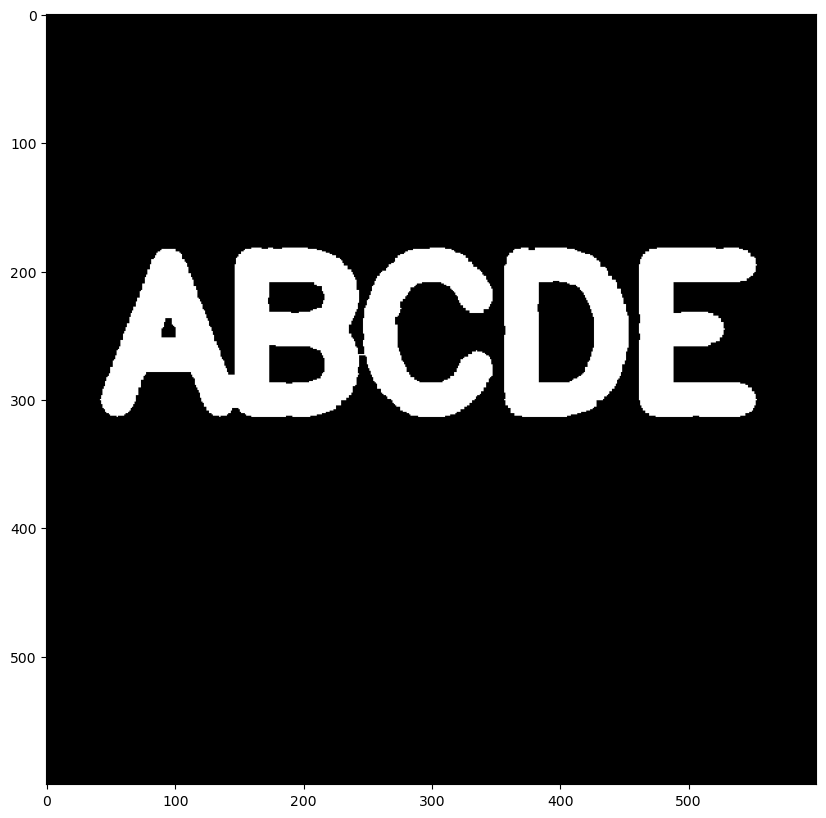

In [38]:
# Try closing instead to remove foreground noise
closing = cv2.morphologyEx(black_noise_img, cv2.MORPH_CLOSE, kernel)
display_img(closing)

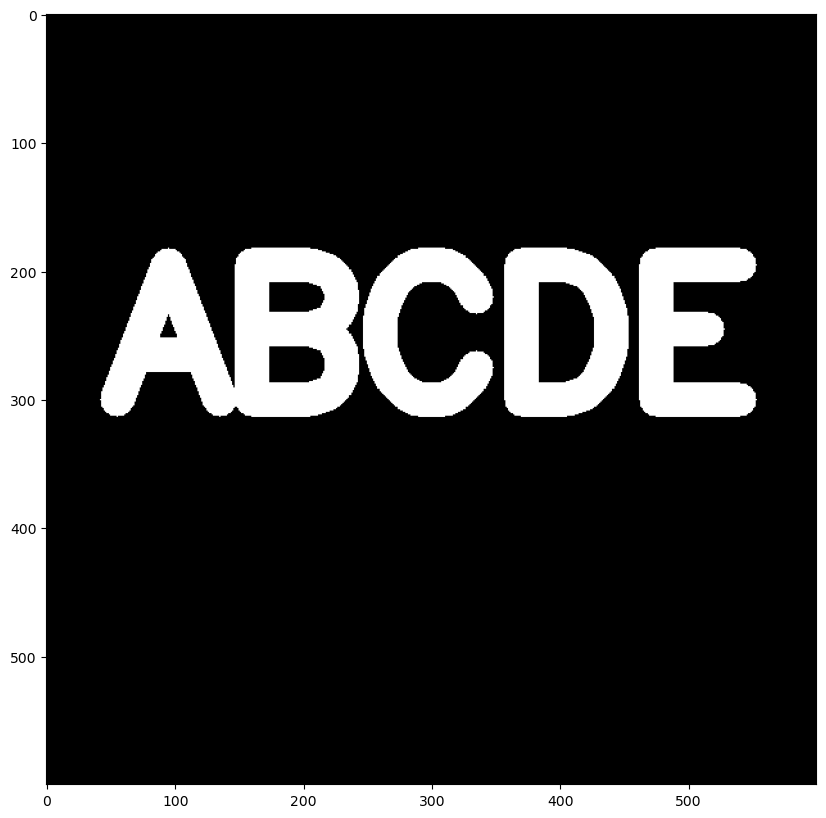

In [39]:
# Gradient - Shows the difference between dilation and erosion
img = load_img()
display_img(img)

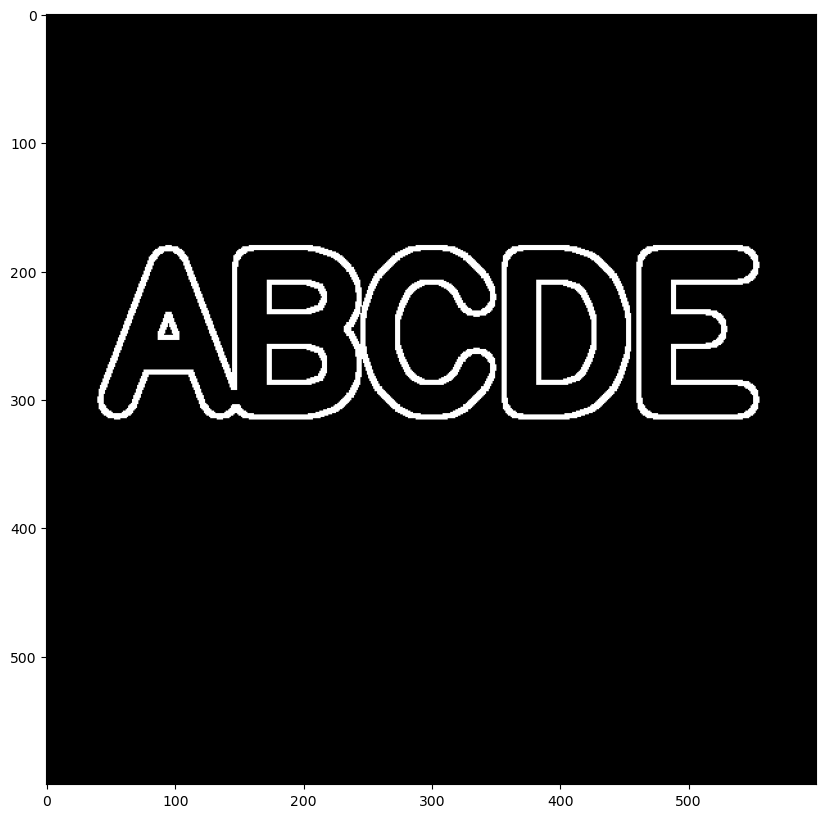

In [40]:
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)
display_img(gradient)